<a href="https://colab.research.google.com/github/Rusdianto-lab/markov-chain-transportasi-online/blob/main/analisis_markov_chain_transportasi_online.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving data_jakarta_gojek_grab.csv to data_jakarta_gojek_grab (3).csv
DATA AWAL
  responden_id     kota     gender kelompok_usia   periode  urutan_periode  \
0       JKT001  Jakarta  Laki-laki   20-30 tahun  Nov-2022               1   
1       JKT001  Jakarta  Laki-laki   20-30 tahun  Des-2022               2   
2       JKT001  Jakarta  Perempuan   30-49 tahun  Jan-2023               3   
3       JKT002  Jakarta  Perempuan   30-49 tahun  Nov-2022               1   
4       JKT002  Jakarta  Laki-laki   30-49 tahun  Des-2022               2   

  aplikasi_sebelumnya aplikasi_digunakan status_perpindahan  \
0                   -              Gojek               Awal   
1               Gojek               Grab             Pindah   
2                Grab              Gojek             Pindah   
3                   -              Gojek               Awal   
4               Gojek              Gojek              Tetap   

        alasan_perpindahan  estimasi_tarif_idr  
0             Pilihan a

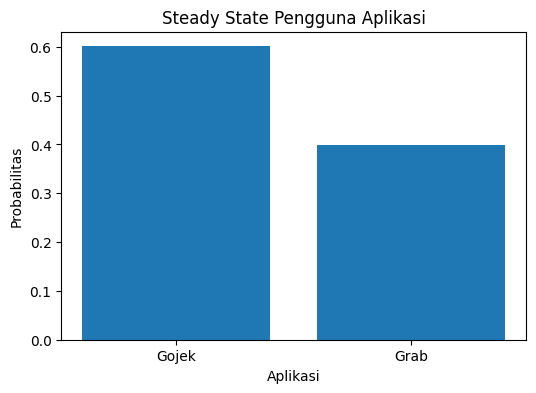

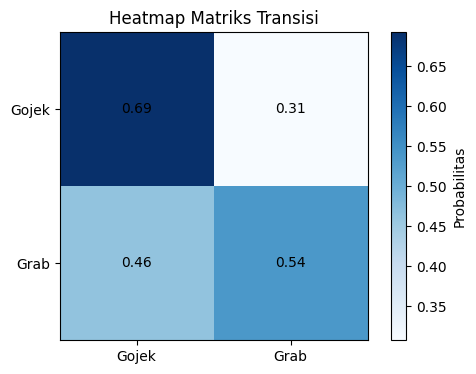

In [4]:
# ANALISIS RANTAI MARKOV
# Perpindahan Pengguna Gojek dan Grab
import pandas as pd
import numpy as np
import random
from google.colab import files
import io
import matplotlib.pyplot as plt

# Upload Dataset
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Menampilkan Data Awal
print("DATA AWAL")
print(df.head())

# Preprocessing Data
# Menghapus data awal
df = df[df['aplikasi_sebelumnya'] != '-']
print("\nJUMLAH DATA SETELAH CLEANING")
print(len(df))

# Membuat Tabel Frekuensi Transisi
transition_table = pd.crosstab(
    df['aplikasi_sebelumnya'],
    df['aplikasi_digunakan']
)

print("\nFREKUENSI TRANSISI")
print(transition_table)

# Matriks Probabilitas Transisi
transition_matrix = transition_table.div(
    transition_table.sum(axis=1),
    axis=0
)

print("\nMATRIKS PROBABILITAS TRANSISI")
print(transition_matrix)

# Membuat Class Markov Chain
class MarkovChain:

    def __init__(self, states, transition_matrix):

        self.states = states

        self.transition_matrix = np.array(transition_matrix)

        self.num_states = len(states)

        # Mengecek ukuran matriks
        if self.transition_matrix.shape != (self.num_states, self.num_states):
            raise ValueError("Ukuran matriks tidak sesuai")

        # Mengecek jumlah probabilitas tiap baris
        if not np.allclose(self.transition_matrix.sum(axis=1), 1.0):
            raise ValueError("Jumlah probabilitas tiap baris harus 1")

        self.state_to_index = {
            state: i for i, state in enumerate(states)
        }

        self.index_to_state = {
            i: state for i, state in enumerate(states)
        }

        # Menentukan State Berikutnya

    def get_next_state(self, current_state):

        current_index = self.state_to_index[current_state]

        probabilities = self.transition_matrix[current_index]

        next_index = random.choices(
            range(self.num_states),
            weights=probabilities
        )[0]

        return self.index_to_state[next_index]

        # Simulasi Markov Chain

    def simulate(self, start_state, num_steps):

        current_state = start_state

        states_history = [current_state]

        for _ in range(num_steps):

            next_state = self.get_next_state(current_state)

            states_history.append(next_state)

            current_state = next_state

        return states_history


# Membuat Objek Markov Chain
states = list(transition_matrix.index)

P = transition_matrix.values

mc = MarkovChain(states, P)

# Simulasi Perpindahan Pengguna
print("\nSIMULASI PERPINDAHAN PENGGUNA")

simulation = mc.simulate(
    start_state='Gojek',
    num_steps=10
)

print(simulation)

# Menghitung Steady State
n = P.shape[0]
A = np.transpose(P) - np.eye(n)
A = np.vstack([A, np.ones(n)])
b = np.array([0] * n + [1])
steady_state = np.linalg.lstsq(A, b, rcond=None)[0]

# Menampilkan Steady State
print("\nSTEADY STATE")
for state, prob in zip(states, steady_state):

    print(f"{state}: {prob:.4f}")

# Simulasi Matriks Setelah 5 Periode
print("\nMATRIKS TRANSISI SETELAH 5 PERIODE")
P5 = np.linalg.matrix_power(P, 5)
P5_df = pd.DataFrame(
    P5,
    index=states,
    columns=states
)

print(P5_df)

# Bar Chart Steady State
plt.figure(figsize=(6,4))
plt.bar(states, steady_state)
plt.title('Steady State Pengguna Aplikasi')
plt.xlabel('Aplikasi')
plt.ylabel('Probabilitas')
plt.show()

# Heatmap Matriks Transisi
plt.figure(figsize=(6,4))
plt.imshow(P, cmap='Blues')
plt.colorbar(label='Probabilitas')
plt.xticks(range(len(states)), states)
plt.yticks(range(len(states)), states)
plt.title('Heatmap Matriks Transisi')
for i in range(len(states)):
    for j in range(len(states)):
        plt.text(
            j,
            i,
            round(P[i, j], 2),
            ha='center',
            va='center'
        )
plt.show()